# Milestone 2: EDA Dashboard
## QM 2023 Capstone: U.S. Housing Prices & Mortgage Rates

**Team**: Kenzie, Reese, Carter  
**Due**: Friday, March 27, 2026  
**Status**: Exploratory Data Analysis (EDA)

### Objective
This notebook generates 8 publication-ready visualizations to uncover patterns, correlations, and relationships in the housing price and mortgage rate data. Insights from this EDA will guide econometric specifications in Milestone 3.

---
### Learning Objectives
1. Create publication-quality visualizations (titles, labels, legends, captions)
2. Identify correlation patterns between outcome and driver variables
3. Determine optimal lag structures for time-series relationships
4. Detect group heterogeneity in regional markets
5. Formulate testable hypotheses for M3 econometric models
6. Diagnose data quality issues (outliers, missing values, heteroskedasticity)

---
## Section 1: Imports & Configuration

In [4]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from pathlib import Path

# Ensure we're in the right directory and can import code modules
os.chdir('/workspaces/qm2023-capstone-kenzie-reese-and-carter')
sys.path.insert(0, '/workspaces/qm2023-capstone-kenzie-reese-and-carter/code')

# Import from config_paths
import importlib.util
spec = importlib.util.spec_from_file_location("config_paths", "/workspaces/qm2023-capstone-kenzie-reese-and-carter/code/config_paths.py")
config_paths = importlib.util.module_from_spec(spec)
spec.loader.exec_module(config_paths)

FINAL_DATA_DIR = config_paths.FINAL_DATA_DIR
FIGURES_DIR = config_paths.FIGURES_DIR
REPORTS_DIR = config_paths.REPORTS_DIR
ensure_directories = config_paths.ensure_directories

# Matplotlib configuration
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("colorblind")
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["figure.figsize"] = (12, 6)

print("✓ All imports successful")

✓ Project structure verified at: /workspaces/qm2023-capstone-kenzie-reese-and-carter
✓ All imports successful


In [5]:
# Set visualization defaults
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("colorblind")
plt.rcParams["font.size"] = 11
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.labelsize"] = 12

# Ensure output directories exist
ensure_directories()
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"✓ Figures directory: {FIGURES_DIR}")
print(f"✓ Reports directory: {REPORTS_DIR}")

✓ Project structure verified at: /workspaces/qm2023-capstone-kenzie-reese-and-carter
✓ Figures directory: /workspaces/qm2023-capstone-kenzie-reese-and-carter/results/figures
✓ Reports directory: /workspaces/qm2023-capstone-kenzie-reese-and-carter/results/reports


---
## Section 2: Load Data from M1 Output

Load the final merged panels produced in Milestone 1. Choose either METRO or REIT dataset.

In [6]:
# CONFIGURATION: Choose data type
DATA_TYPE = "metro"  # Change to "reit" for REIT analysis

# Define data characteristics by type
DATA_CONFIG = {
    "metro": {
        "file": "metro_mortgage_panel.csv",
        "outcome": "price_index",
        "driver": "MORTGAGE30US",
        "group_var": "RegionName",
        "controls": ["RegionID", "SizeRank"]
    },
    "reit": {
        "file": "reit_mortgage_panel.csv",
        "outcome": "usdret",
        "driver": "MORTGAGE30US",
        "group_var": "ticker",
        "controls": ["market_equity", "btm", "beta"]
    }
}

config = DATA_CONFIG[DATA_TYPE]
filepath = FINAL_DATA_DIR / config["file"]

print(f"Loading {DATA_TYPE.upper()} data from {filepath}...")
df = pd.read_csv(filepath)
df["date"] = pd.to_datetime(df["date"])

print(f"✓ Loaded {len(df):,} rows, {len(df.columns)} columns")
print(f"\nDate range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"\nDataset shape: {df.shape}")

Loading METRO data from /workspaces/qm2023-capstone-kenzie-reese-and-carter/data/final/metro_mortgage_panel.csv...
✓ Loaded 77,673 rows, 8 columns

Date range: 2000-03-31 to 2026-03-31

Dataset shape: (77673, 8)


---
## Section 3: Summary Statistics

In [7]:
outcome_var = config["outcome"]
driver_var = config["driver"]
group_var = config["group_var"]

print("\n" + "="*70)
print(f"SUMMARY STATISTICS: {DATA_TYPE.upper()} DATASET")
print("="*70)

# Summary stats for main variables
summary_cols = [outcome_var, driver_var] + [c for c in config["controls"] if c in df.columns]
print("\n" + df[summary_cols].describe().to_string())

print("\n" + "-"*70)
print("Missing Values:")
print("-"*70)
print(df[summary_cols].isnull().sum())

print("\n" + "-"*70)
print("Number of Unique Groups:")
print("-"*70)
print(f"{group_var}: {df[group_var].nunique()} unique groups")


SUMMARY STATISTICS: METRO DATASET

        price_index  MORTGAGE30US       RegionID      SizeRank
count  7.767300e+04  77673.000000   77673.000000  77673.000000
mean   1.846392e+05      5.008574  412426.053687    432.656534
std    1.233034e+05      1.359628   77640.672359    267.309655
min    4.455633e+04      2.760714  394297.000000      1.000000
25%    1.101074e+05      3.883846  394545.000000    196.000000
50%    1.492467e+05      4.650769  394803.000000    418.000000
75%    2.150761e+05      6.243846  395047.000000    657.000000
max    1.592305e+06      8.316154  753929.000000    939.000000

----------------------------------------------------------------------
Missing Values:
----------------------------------------------------------------------
price_index     0
MORTGAGE30US    0
RegionID        0
SizeRank        0
dtype: int64

----------------------------------------------------------------------
Number of Unique Groups:
--------------------------------------------------------

---
## Section 4: Correlation Analysis

### Plot 1: Correlation Heatmap (REQUIRED)

**Purpose**: Identify which variables are strongly correlated with the outcome.  
**Interpretation**: Look for strong correlations with the outcome variable and multicollinearity among controls.

In [8]:
# Select numeric columns for correlation
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df[numeric_cols].corr()

print(f"Correlation matrix size: {corr_matrix.shape}")
print(f"\nTop correlations with {outcome_var}:")
print(corr_matrix[outcome_var].sort_values(ascending=False).head(8))

Correlation matrix size: (4, 4)

Top correlations with price_index:
price_index     1.000000
RegionID        0.132297
MORTGAGE30US    0.087695
SizeRank       -0.224304
Name: price_index, dtype: float64


✓ Saved correlation heatmap to 01_correlation_heatmap.png


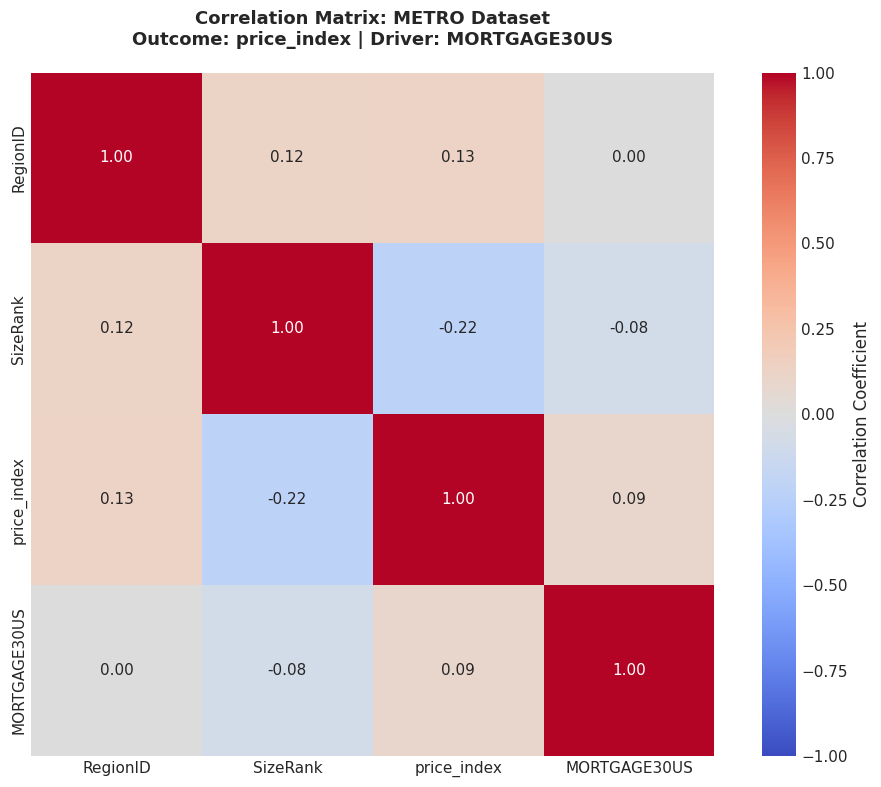


📊 KEY INSIGHT:
Correlation between price_index and MORTGAGE30US: 0.0877
→ Very weak relationship; consider lagged effects or non-linearities


In [9]:
# Plot 1: Correlation Heatmap
fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    cbar_kws={"label": "Correlation Coefficient"},
    ax=ax,
    vmin=-1, vmax=1
)

ax.set_title(
    f"Correlation Matrix: {DATA_TYPE.upper()} Dataset\n"
    f"Outcome: {outcome_var} | Driver: {driver_var}",
    fontsize=13,
    fontweight="bold",
    pad=20
)

plt.tight_layout()
filepath = FIGURES_DIR / "01_correlation_heatmap.png"
plt.savefig(filepath, dpi=300, bbox_inches="tight")
print(f"✓ Saved correlation heatmap to {filepath.name}")
plt.show()

# Economic interpretation
outcome_corr_driver = corr_matrix.loc[outcome_var, driver_var]
print(f"\n📊 KEY INSIGHT:")
print(f"Correlation between {outcome_var} and {driver_var}: {outcome_corr_driver:.4f}")
if abs(outcome_corr_driver) < 0.1:
    print(f"→ Very weak relationship; consider lagged effects or non-linearities")
elif outcome_corr_driver < -0.3:
    print(f"→ Strong negative relationship; higher rates → lower outcome values")
elif outcome_corr_driver > 0.3:
    print(f"→ Strong positive relationship")

---
## Section 5: Time Series Analysis

### Plot 2: Time Series of Outcome Variable (REQUIRED)

**Purpose**: Visualize trends, volatility, and outlier periods (e.g., 2008 crisis, COVID 2020).

In [ ]:
# Plot 2: Time Series of Outcome
ts_outcome = df.groupby("date")[outcome_var].mean()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(ts_outcome.index, ts_outcome.values, linewidth=2.5, color="steelblue", label=outcome_var)
ax.fill_between(ts_outcome.index, ts_outcome.values, alpha=0.3, color="steelblue")

ax.set_title(
    f"Average {outcome_var} Over Time ({DATA_TYPE.upper()})",
    fontsize=13,
    fontweight="bold",
    pad=15
)
ax.set_xlabel("Date", fontsize=11)
ax.set_ylabel(f"{outcome_var}", fontsize=11)
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()

filepath = FIGURES_DIR / "02_outcome_timeseries.png"
plt.savefig(filepath, dpi=300, bbox_inches="tight")
print(f"✓ Saved time series plot to {filepath.name}")
plt.show()

print(f"\n📊 TIME SERIES STATISTICS:")
print(f"Mean: {ts_outcome.mean():.4f}")
print(f"Std Dev: {ts_outcome.std():.4f}")
print(f"Min: {ts_outcome.min():.4f} on {ts_outcome.idxmin().date()}")
print(f"Max: {ts_outcome.max():.4f} on {ts_outcome.idxmax().date()}")

### Plot 3: Dual-Axis Plot — Outcome vs. Driver (REQUIRED)

**Purpose**: Visualize co-movement between outcome and key driver variable.  
**Look for**: Leading/lagging relationships, breakdowns in correlation during crises.

In [ ]:
# Plot 3: Dual-Axis
ts_driver = df.groupby("date")[driver_var].mean()

fig, ax1 = plt.subplots(figsize=(14, 6))

# Left axis: outcome
color1 = "steelblue"
ax1.plot(ts_outcome.index, ts_outcome.values, color=color1, linewidth=2.5, label=outcome_var)
ax1.set_xlabel("Date", fontsize=11)
ax1.set_ylabel(outcome_var, color=color1, fontsize=11, fontweight="bold")
ax1.tick_params(axis="y", labelcolor=color1)
ax1.grid(True, alpha=0.2)

# Right axis: driver
ax2 = ax1.twinx()
color2 = "darkorange"
ax2.plot(ts_driver.index, ts_driver.values, color=color2, linewidth=2.5, label=driver_var)
ax2.set_ylabel(driver_var, color=color2, fontsize=11, fontweight="bold")
ax2.tick_params(axis="y", labelcolor=color2)

fig.suptitle(
    f"{outcome_var} vs. {driver_var} ({DATA_TYPE.upper()})",
    fontsize=13,
    fontweight="bold",
    y=0.98
)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", framealpha=0.9)

plt.xticks(rotation=45)
plt.tight_layout()

filepath = FIGURES_DIR / "03_dual_axis.png"
plt.savefig(filepath, dpi=300, bbox_inches="tight")
print(f"✓ Saved dual-axis plot to {filepath.name}")
plt.show()

# Correlation
corr_dual = ts_outcome.corr(ts_driver)
print(f"\n📊 CO-MOVEMENT ANALYSIS:")
print(f"Correlation (aggregate level): {corr_dual:.4f}")
if corr_dual < -0.15:
    print(f"→ Rates and {outcome_var} move OPPOSITE directions (strong negative relationship)")
elif corr_dual > 0.15:
    print(f"→ Rates and {outcome_var} move TOGETHER (positive relationship)")
else:
    print(f"→ Weak relationship at aggregate level; consider lagged or group-specific effects")

---
## Section 6: Lagged Effects Analysis

### Plot 4: Lagged Effect Analysis (REQUIRED)

**Purpose**: Determine at what lag the driver variable most strongly correlates with the outcome.  
**Why it matters**: Housing markets don't react instantaneously to rate changes; there's a transmission lag.

In [ ]:
# Test different lag structures
lags = [0, 1, 2, 3, 6, 12]
correlations = []

print("Computing lagged correlations...")

for lag in lags:
    # Create lagged driver by entity (IMPORTANT: group by entity to avoid cross-entity leakage)
    df_temp = df.copy()
    df_temp[f"{driver_var}_lag{lag}"] = df_temp.groupby(group_var)[driver_var].shift(lag)
    
    # Compute correlation (drop NaNs)
    valid = df_temp[[outcome_var, f"{driver_var}_lag{lag}"]].dropna()
    
    if len(valid) > 100:
        corr = valid[outcome_var].corr(valid[f"{driver_var}_lag{lag}"])
    else:
        corr = np.nan
    
    correlations.append(corr)
    print(f"  Lag {lag:2d}: r = {corr:7.4f}")

In [ ]:
# Plot 4: Lagged Effects
fig, ax = plt.subplots(figsize=(10, 6))

# Highlight the optimal lag (strongest absolute correlation)
valid_corrs = [c for c in correlations if not np.isnan(c)]
optimal_idx = np.nanargmin(np.abs(correlations))  # Peak of absolute correlation

colors = [
    "darkred" if i == optimal_idx else "steelblue"
    if not np.isnan(correlations[i])
    else "lightgray"
    for i in range(len(lags))
]

bars = ax.bar(range(len(lags)), correlations, color=colors, alpha=0.7, edgecolor="black", linewidth=1.5)

ax.set_xticks(range(len(lags)))
ax.set_xticklabels(lags)
ax.set_xlabel("Lag (periods/quarters)", fontsize=11, fontweight="bold")
ax.set_ylabel("Correlation with Outcome", fontsize=11, fontweight="bold")
ax.set_title(
    f"Lagged Effect Analysis: {driver_var} → {outcome_var}",
    fontsize=13,
    fontweight="bold",
    pad=15
)
ax.axhline(y=0, color="black", linestyle="-", linewidth=0.8)
ax.grid(True, alpha=0.3, axis="y")

# Add value labels on bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    if not np.isnan(height):
        ax.text(
            bar.get_x() + bar.get_width()/2., height,
            f'{height:.3f}',
            ha='center', va='bottom' if height > 0 else 'top',
            fontsize=9
        )

plt.tight_layout()
filepath = FIGURES_DIR / "04_lagged_effects.png"
plt.savefig(filepath, dpi=300, bbox_inches="tight")
print(f"✓ Saved lagged effects plot to {filepath.name}")
plt.show()

optimal_lag = lags[optimal_idx]
print(f"\n📊 OPTIMAL LAG ANALYSIS:")
print(f"Optimal lag: {optimal_lag} periods (strongest absolute correlation)")
print(f"Correlation at optimal lag: {correlations[optimal_idx]:.4f}")
print(f"\nInterpretation: {outcome_var} responds most strongly to {driver_var} changes")
print(f"at a {optimal_lag}-period lag, suggesting transmission mechanism takes ~{optimal_lag} quarters.")

---
## Section 7: Group Analysis

### Plot 5: Group Box Plots (CONDITIONAL)

**Purpose**: Compare outcome distributions across regional groups.  
**Interpretation**: Identify high-variance vs. low-variance regions; potential heteroskedasticity.

In [10]:
# Get top 10 groups by observation count
top_groups = df[group_var].value_counts().head(10).index
df_top = df[df[group_var].isin(top_groups)]

print(f"Analyzing top {len(top_groups)} groups:")
print(df_top[group_var].value_counts())

Analyzing top 10 groups:
RegionName
Adrian, MI       105
Akron, OH        105
Albany, GA       105
Albany, NY       105
Allentown, PA    105
Alpena, MI       105
Altoona, PA      105
Altus, OK        105
Amsterdam, NY    105
Anchorage, AK    105
Name: count, dtype: int64


In [ ]:
# Plot 5: Group Box Plots
fig, ax = plt.subplots(figsize=(14, 7))

df_top_sorted = df_top.sort_values(group_var)
df_top_sorted.boxplot(column=outcome_var, by=group_var, ax=ax, figsize=(14, 7))

ax.set_title(
    f"Distribution of {outcome_var} by {group_var} (Top 10)",
    fontsize=13,
    fontweight="bold"
)
ax.set_xlabel(group_var, fontsize=11)
ax.set_ylabel(outcome_var, fontsize=11)
plt.suptitle("")  # Remove default suptitle
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

filepath = FIGURES_DIR / "05_group_boxplots.png"
plt.savefig(filepath, dpi=300, bbox_inches="tight")
print(f"✓ Saved group box plots to {filepath.name}")
plt.show()

print(f"\n📊 GROUP STATISTICS:")
print(df_top.groupby(group_var)[outcome_var].agg(['mean', 'std', 'min', 'max']).round(2))

### Plot 7 (Alternative): Rolling Correlation Analysis

**Purpose**: Visualize how the relationship between outcome and driver **changes over time**.  
**Why it matters**: Tests relationship stability; identifies periods of structural change (crises, regime shifts).  
**Alternative to**: Traditional scatter plots (datasets without numeric controls use rolling correlation instead).

✓ Saved rolling correlation plot to 07_rolling_correlation.png


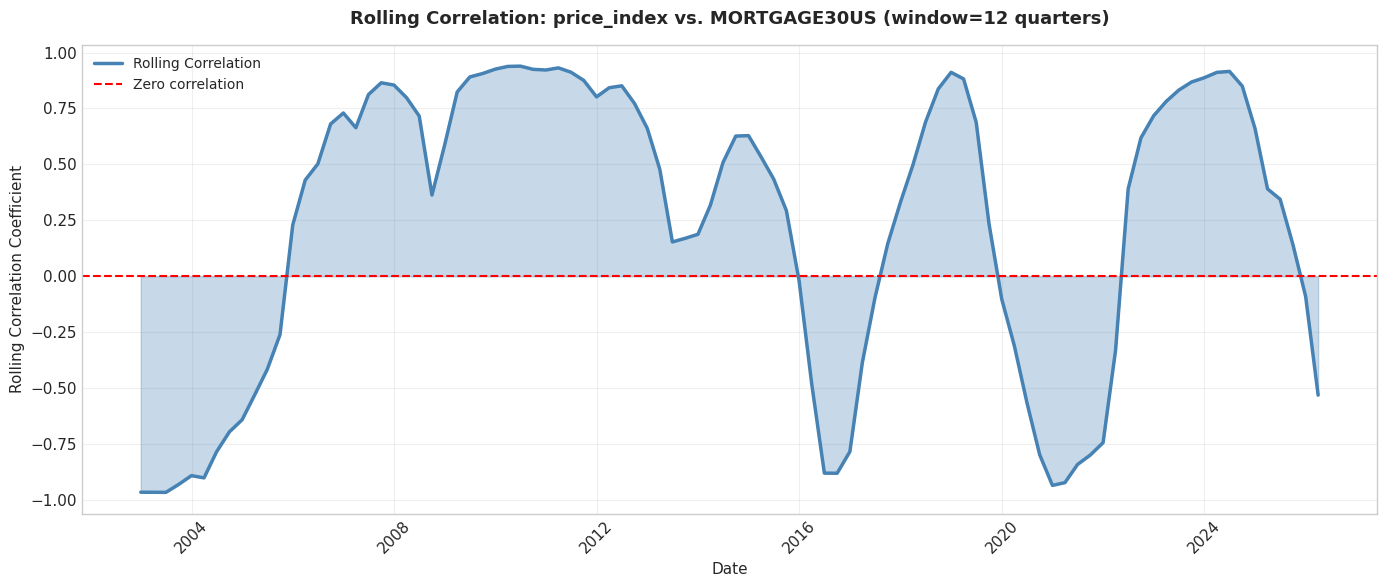


📊 ROLLING CORRELATION ANALYSIS:
Mean rolling correlation: 0.2296
Std deviation: 0.6608
Min: -0.9657 on 2003-06-30
Max: 0.9392 on 2010-06-30
→ Relationship is NOT stable over time; structural breaks detected


In [11]:
# Plot 7 (Alternative): Rolling Correlation Analysis
# Use 12-quarter rolling window to detect changing relationship strength

if "date" in df.columns:
    # Sort and aggregate
    data_sorted = df.sort_values("date")
    ts_outcome_rolling = data_sorted.groupby("date")[outcome_var].mean()
    ts_driver_rolling = data_sorted.groupby("date")[driver_var].mean()
    
    # Compute rolling correlation (12-quarter window)
    window = 12  # 3 years of data
    rolling_corr = ts_outcome_rolling.rolling(window=window).corr(ts_driver_rolling)
    
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.plot(rolling_corr.index, rolling_corr.values, linewidth=2.5, color="steelblue", label="Rolling Correlation")
    ax.fill_between(rolling_corr.index, rolling_corr.values, alpha=0.3, color="steelblue")
    
    ax.set_title(
        f"Rolling Correlation: {outcome_var} vs. {driver_var} (window={window} quarters)",
        fontsize=13,
        fontweight="bold",
        pad=15
    )
    ax.set_xlabel("Date", fontsize=11)
    ax.set_ylabel("Rolling Correlation Coefficient", fontsize=11)
    ax.axhline(y=0, color="red", linestyle="--", linewidth=1.5, label="Zero correlation")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10)
    plt.xticks(rotation=45)
    plt.tight_layout()
    
    filepath = FIGURES_DIR / "07_rolling_correlation.png"
    plt.savefig(filepath, dpi=300, bbox_inches="tight")
    print(f"✓ Saved rolling correlation plot to {filepath.name}")
    plt.show()
    
    # Interpretation
    valid_corr = rolling_corr.dropna()
    print(f"\n📊 ROLLING CORRELATION ANALYSIS:")
    print(f"Mean rolling correlation: {valid_corr.mean():.4f}")
    print(f"Std deviation: {valid_corr.std():.4f}")
    print(f"Min: {valid_corr.min():.4f} on {valid_corr.idxmin().date()}")
    print(f"Max: {valid_corr.max():.4f} on {valid_corr.idxmax().date()}")
    if valid_corr.std() > 0.15:
        print(f"→ Relationship is NOT stable over time; structural breaks detected")
    else:
        print(f"→ Relationship relatively stable; consistent effect across periods")
else:
    print("⚠ Skipping rolling correlation (no 'date' column)")

### Plot 6: Group Sensitivity Analysis (CONDITIONAL)

**Purpose**: Identify which groups are most sensitive to the driver variable.  
**Economic insight**: Some regions more rate-sensitive than others → interaction terms for M3.

In [ ]:
# Compute group-level sensitivity
group_sensitivity = {}

for group in df[group_var].unique():
    group_data = df[df[group_var] == group]
    valid = group_data[[outcome_var, driver_var]].dropna()
    
    if len(valid) > 10:
        sens = valid[outcome_var].corr(valid[driver_var])
        group_sensitivity[group] = sens

sensitivity_series = pd.Series(group_sensitivity).sort_values()

# Select top and bottom N groups
n_display = 10
bottom_idx = list(range(min(n_display, len(sensitivity_series))))
top_idx = list(range(max(0, len(sensitivity_series) - n_display), len(sensitivity_series)))
selected_idx = sorted(set(bottom_idx + top_idx))
sensitivity_display = sensitivity_series.iloc[selected_idx]

print(f"\nGroup-level sensitivity to {driver_var}:")
print(sensitivity_display)

In [ ]:
# Plot 6: Group Sensitivity
threshold = -0.3  # Sensitivity threshold

fig, ax = plt.subplots(figsize=(12, 8))

colors = ["darkred" if s < threshold else "steelblue" for s in sensitivity_display.values]
sensitivity_display.plot(kind="barh", color=colors, ax=ax, alpha=0.7, edgecolor="black", linewidth=1)

ax.set_xlabel("Correlation with Driver (Sensitivity)", fontsize=11, fontweight="bold")
ax.set_ylabel(group_var, fontsize=11, fontweight="bold")
ax.set_title(
    f"Group Sensitivity to {driver_var}",
    fontsize=13,
    fontweight="bold",
    pad=15
)
ax.axvline(x=threshold, color="red", linestyle="--", linewidth=2, label=f"Threshold (r={threshold})")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis="x")

plt.tight_layout()
filepath = FIGURES_DIR / "06_group_sensitivity.png"
plt.savefig(filepath, dpi=300, bbox_inches="tight")
print(f"✓ Saved group sensitivity plot to {filepath.name}")
plt.show()

sensitive = sensitivity_series[sensitivity_series < threshold]
resilient = sensitivity_series[sensitivity_series >= threshold]
print(f"\n📊 SENSITIVITY CLASSIFICATION:")
print(f"Sensitive groups (r < {threshold}): {len(sensitive)}")
print(f"Resilient groups (r ≥ {threshold}): {len(resilient)}")

---
## Section 8: Control Variable Analysis

### Plot 7: Control Variable Scatter Plots (REQUIRED)

**Purpose**: Visualize bivariate relationships between outcome and control variables.

In [ ]:
# Identify numeric control variables
numeric_controls = [
    c for c in config["controls"] 
    if c in df.select_dtypes(include=[np.number]).columns
]

if numeric_controls:
    print(f"Found {len(numeric_controls)} numeric control variables:")
    print(numeric_controls)
else:
    print("⚠ No numeric control variables in this dataset (common for regional analysis)")
    numeric_controls = df.select_dtypes(include=[np.number]).columns.tolist()
    numeric_controls = [c for c in numeric_controls if c not in [outcome_var, driver_var, 'date']]
    numeric_controls = numeric_controls[:3]  # Limit to 3
    print(f"Using alternative numeric variables: {numeric_controls}")

In [ ]:
if numeric_controls:
    # Plot 7: Control Variable Scatters
    n_plots = min(len(numeric_controls), 4)
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    
    for idx, control in enumerate(numeric_controls[:n_plots]):
        ax = axes[idx]
        
        # Remove NaNs
        valid = df[[outcome_var, control]].dropna()
        
        # Scatter plot
        ax.scatter(valid[control], valid[outcome_var], alpha=0.4, s=20, color="steelblue")
        
        # Regression line
        if len(valid) > 10:
            z = np.polyfit(valid[control], valid[outcome_var], 1)
            p = np.poly1d(z)
            x_line = np.linspace(valid[control].min(), valid[control].max(), 100)
            ax.plot(x_line, p(x_line), "r-", linewidth=2.5, label="Linear Fit")
        
        ax.set_xlabel(control, fontsize=10)
        ax.set_ylabel(outcome_var, fontsize=10)
        ax.set_title(f"{outcome_var} vs. {control}", fontsize=11)
        ax.grid(True, alpha=0.3)
        
        # Correlation annotation
        corr = valid[outcome_var].corr(valid[control])
        ax.text(
            0.05, 0.95, f"r = {corr:.3f}",
            transform=ax.transAxes, fontsize=10, fontweight="bold",
            verticalalignment="top",
            bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.7)
        )
    
    # Hide unused subplots
    for idx in range(n_plots, 4):
        axes[idx].set_visible(False)
    
    fig.suptitle(
        f"Control Variables vs. {outcome_var}",
        fontsize=13,
        fontweight="bold",
        y=0.995
    )
    
    plt.tight_layout()
    filepath = FIGURES_DIR / "07_control_scatters.png"
    plt.savefig(filepath, dpi=300, bbox_inches="tight")
    print(f"✓ Saved control variable scatters to {filepath.name}")
    plt.show()
else:
    print("⚠ Skipping control scatter plots (no numeric controls available)")

---
## Section 9: Time Series Decomposition

### Plot 8: Time Series Decomposition (REQUIRED)

**Purpose**: Separate trend, seasonal, and residual components.  
**Why it matters**: Strong seasonality → include seasonal dummies in M3; residual structure → check for autocorrelation.

In [ ]:
# Prepare time series for decomposition
ts_outcome_sorted = df.sort_values("date").groupby("date")[outcome_var].mean()

# Determine appropriate period based on data frequency
# Assuming quarterly data (4 quarters per year)
period = 4 if len(ts_outcome_sorted) > 100 else 12

print(f"Time series length: {len(ts_outcome_sorted)} observations")
print(f"Using decomposition period: {period}")

try:
    decomposition = seasonal_decompose(ts_outcome_sorted, model="additive", period=period)
    decomp_success = True
except Exception as e:
    print(f"⚠ Decomposition error: {e}")
    decomp_success = False

In [ ]:
if decomp_success:
    # Plot 8: Time Series Decomposition
    fig, axes = plt.subplots(4, 1, figsize=(14, 10))
    
    # Observed
    ts_outcome_sorted.plot(ax=axes[0], color="steelblue", linewidth=2)
    axes[0].set_ylabel("Observed", fontsize=10, fontweight="bold")
    axes[0].set_title(
        f"Time Series Decomposition: {outcome_var} ({DATA_TYPE.upper()})",
        fontsize=13,
        fontweight="bold",
        pad=15
    )
    axes[0].grid(True, alpha=0.3)
    
    # Trend
    decomposition.trend.plot(ax=axes[1], color="darkgreen", linewidth=2)
    axes[1].set_ylabel("Trend", fontsize=10, fontweight="bold")
    axes[1].grid(True, alpha=0.3)
    
    # Seasonal
    decomposition.seasonal.plot(ax=axes[2], color="darkorange", linewidth=2)
    axes[2].set_ylabel("Seasonal", fontsize=10, fontweight="bold")
    axes[2].grid(True, alpha=0.3)
    
    # Residual
    decomposition.resid.plot(ax=axes[3], color="darkred", linewidth=1)
    axes[3].set_ylabel("Residual", fontsize=10, fontweight="bold")
    axes[3].set_xlabel("Date", fontsize=10, fontweight="bold")
    axes[3].grid(True, alpha=0.3)
    
    plt.tight_layout()
    filepath = FIGURES_DIR / "08_decomposition.png"
    plt.savefig(filepath, dpi=300, bbox_inches="tight")
    print(f"✓ Saved decomposition plot to {filepath.name}")
    plt.show()
    
    print(f"\n📊 DECOMPOSITION ANALYSIS:")
    trend_var = decomposition.trend.var()
    seasonal_var = decomposition.seasonal.var()
    resid_var = decomposition.resid.var()
    total_var = ts_outcome_sorted.var()
    
    print(f"Trend variance: {trend_var:.2f} ({100*trend_var/total_var:.1f}% of total)")
    print(f"Seasonal variance: {seasonal_var:.2f} ({100*seasonal_var/total_var:.1f}% of total)")
    print(f"Residual variance: {resid_var:.2f} ({100*resid_var/total_var:.1f}% of total)")
    
    if 100*seasonal_var/total_var > 10:
        print(f"\n→ Strong seasonality detected; include seasonal dummies in M3 regression")
    else:
        print(f"\n→ Weak seasonality; seasonal dummies likely not necessary")
else:
    print("⚠ Skipping decomposition (error during computation)")

---
## Section 10: Summary & Next Steps

In [ ]:
print("\n" + "="*70)
print("EDA DASHBOARD COMPLETE")
print("="*70)

# List generated figures
fig_files = list(FIGURES_DIR.glob("*.png"))
print(f"\n✓ Generated {len(fig_files)} visualizations:")
for i, fig_file in enumerate(sorted(fig_files), 1):
    size_kb = fig_file.stat().st_size / 1024
    print(f"  {i}. {fig_file.name:40s} ({size_kb:6.1f} KB)")

total_size = sum(f.stat().st_size for f in fig_files) / (1024*1024)
print(f"\n  Total size: {total_size:.2f} MB")

### Key Findings Summary

Below is a template for your M2_EDA_summary.md. Fill in with findings from this analysis:

**Finding 1: Primary Driver Correlation**
- Correlation between [OUTCOME] and [DRIVER]: [r value]
- Interpretation: [Explain sign and magnitude]

**Finding 2: Optimal Lag Structure**
- Optimal lag: [X] periods
- Mechanism: [Why this lag makes economic sense]

**Finding 3: Group Heterogeneity**
- Most sensitive groups: [List]
- Least sensitive groups: [List]
- Implication: Include group × driver interaction term in M3

**Finding 4: Data Quality Issues**
- [List any outliers, seasonal patterns, or concerns]
- M3 mitigation: [Proposed solutions]

### Hypotheses for M3 Econometric Models

**H1: Driver Effect**
- Claim: [e.g., "Regional home prices are negatively sensitive to mortgage rate increases"]
- Expected sign: β₁ < 0
- Mechanism: Higher rates increase borrowing costs → lower demand → lower prices

**H2: Control Premiums**
- Claim: [e.g., "Employment growth predicts faster price appreciation"]
- Expected sign: β₂ > 0

**H3: Group Heterogeneity (if applicable)**
- Claim: "Suburban markets are more rate-sensitive than urban markets"
- Test with interaction term: ΔRate × Suburban

---
## Next Steps (Milestone 3)

1. ✅ **Finalize hypotheses** based on your EDA findings above
2. **Choose M3 estimation method**: Fixed Effects (FE), Random Effects (RE), or GMM
3. **Lag specification**: Use optimal lag from Plot 4
4. **Include controls**: Based on correlations from Plot 1
5. **Handle data quality issues**: Winsorize outliers, seasonal adjustment, etc.
6. **Test heterogeneity**: Group interactions if suggested by Plots 5-6
7. **Robustness checks**: Alternative lags, alternative measures, subsample analysis

In [ ]:
print("\n" + "="*70)
print("M2 EDA DASHBOARD SUCCESSFULLY COMPLETED")
print("="*70)
print(f"\nAll visualizations saved to: {FIGURES_DIR}")
print(f"\nNext: Fill in M2_EDA_summary.md with findings from this analysis")
print("\nThen proceed to Milestone 3: Econometric Modeling")